In [6]:
import numpy as np 
import matplotlib.pyplot as plt

### Module 4 functions

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def calculate_lj_properties(r_sq, r_cutoff_sq):
    """
    Calculates reduced potential energy and force magnitude for a pair of atoms.
    Implements the shifted Lennard-Jones potential: phi(r) - phi(rc).
    Returns (potE, force/r).
    """
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)

    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2

    phi = 4 * (inv_r12 - inv_r6)

    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)
    force_by_rc = 48 * inv_rc2 * (inv_rc12 - 0.5 * inv_rc6)
    force_by_r = force_by_r - force_by_rc
    potE = phi - phi_cut + 0.5 * force_by_rc * (r_sq - r_cutoff_sq)

    return potE, force_by_r


def generate_fcc_lattice(n_cells, rho_star):
    """
    Generates an FCC lattice of atoms.
    Returns (positions array of shape (N,3), box length L).
    N = 4 * n_cells^3.
    """
    L = (4 * n_cells**3 / rho_star) ** (1 / 3)
    a = L / n_cells
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)
    return np.array(positions), L


def apply_minimum_image(pos_i, pos_j, L):
    """
    Calculates the shortest distance vector between two atoms using
    the minimum image convention. dx, dy, dz are kept in [-L/2, L/2].
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr


def calculate_total_force(pos, box_length, r_cutoff_sq):
    """Returns (total_pe, forces array of shape (N,3))."""
    N = len(pos)
    forces = np.zeros((N, 3))
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], box_length)
    r_sq = np.sum(dr**2, axis=2)
    r_sq = np.triu(r_sq, k=1)
    mask = (r_sq < r_cutoff_sq) & (r_sq > 0)
    pot, force_by_r = np.zeros_like(r_sq), np.zeros_like(r_sq)
    pot[mask], force_by_r[mask] = calculate_lj_properties(r_sq[mask], r_cutoff_sq)
    f_mat = force_by_r[:, :, np.newaxis] * dr
    forces += np.sum(f_mat, axis=0)
    forces -= np.sum(f_mat, axis=1)
    total_pe = np.sum(pot)
    return total_pe, forces


def calculate_kinetic_energy(vel):
    """K* = 0.5 * sum(v²)  [m* = 1 in reduced units]"""
    return 0.5 * np.sum(vel**2)


def update_neighbor_list(pos, L, r_skin_sq):
    """
    Builds a list of atom pairs (i, j) within the skin radius.
    Uses the Minimum Image Convention. Fully vectorized.
    """
    dr = apply_minimum_image(pos[:, np.newaxis, :], pos[np.newaxis, :, :], L)
    r_sq = np.sum(dr**2, axis=2)
    i_idx, j_idx = np.where(np.triu(r_sq < r_skin_sq, k=1))
    return np.stack([i_idx, j_idx], axis=1)


def calculate_forces_optimized(pos, neighbor_pairs, L, r_cutoff_sq):
    """
    Calculates total forces using only the pairs in the neighbor list.
    Returns (total_pe, forces array of shape (N,3)).
    """
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0.0
    if len(neighbor_pairs) == 0:
        return total_pe, forces

    i_idx = neighbor_pairs[:, 0]
    j_idx = neighbor_pairs[:, 1]

    dr = apply_minimum_image(pos[i_idx], pos[j_idx], L)
    r_sq = np.sum(dr**2, axis=1)

    mask = r_sq < r_cutoff_sq
    pot, force_by_r = calculate_lj_properties(r_sq[mask], r_cutoff_sq)

    f_vec = force_by_r[:, np.newaxis] * dr[mask]
    np.add.at(forces, i_idx[mask], -f_vec)
    np.add.at(forces, j_idx[mask],  f_vec)
    total_pe = np.sum(pot)
    return total_pe, forces


def velocity_verlet_step_opt(pos, vel, force, dt, box_length, r_cutoff_sq, neighbour_list):
    """
    Velocity Verlet step using the optimized neighbor-list force calculation.
    Returns (pos_new, vel_new, pe_new, force_new).
    """
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    pos_new = pos_new % box_length
    vel_mid = vel + 0.5 * force * dt
    pe_new, force_new = calculate_forces_optimized(pos_new, neighbour_list, box_length, r_cutoff_sq)
    vel_new = vel_mid + 0.5 * force_new * dt
    return pos_new, vel_new, pe_new, force_new


### Module 5 functions

In [8]:
def initialize_velocities(N, T_target):
    """
    Assigns initial velocities from a Maxwell-Boltzmann distribution.
    Generates a (N, 3) array with std_dev = sqrt(T_target),
    then removes net momentum so the center-of-mass is stationary.
    """
    sigma = np.sqrt(T_target)
    vel = np.random.normal(loc=0.0, scale=sigma, size=(N, 3))
    vel -= vel.mean(axis=0)  
    return vel


In [9]:
def rescale_velocities ( vel , T_target ) :

    """
    Scales velocities to match the target temperature .
    """
    # 1. Calculate current T_inst = (sum v^2) / 3N
    # 2. Scale factor lambda = sqrt ( T_target / T_inst )
    # 3. vel = vel * lambda
    T_inst = np.sum(vel**2) / (3 * len(vel))
    lambda_factor = np.sqrt(T_target / T_inst)
    vel *= lambda_factor
    return vel


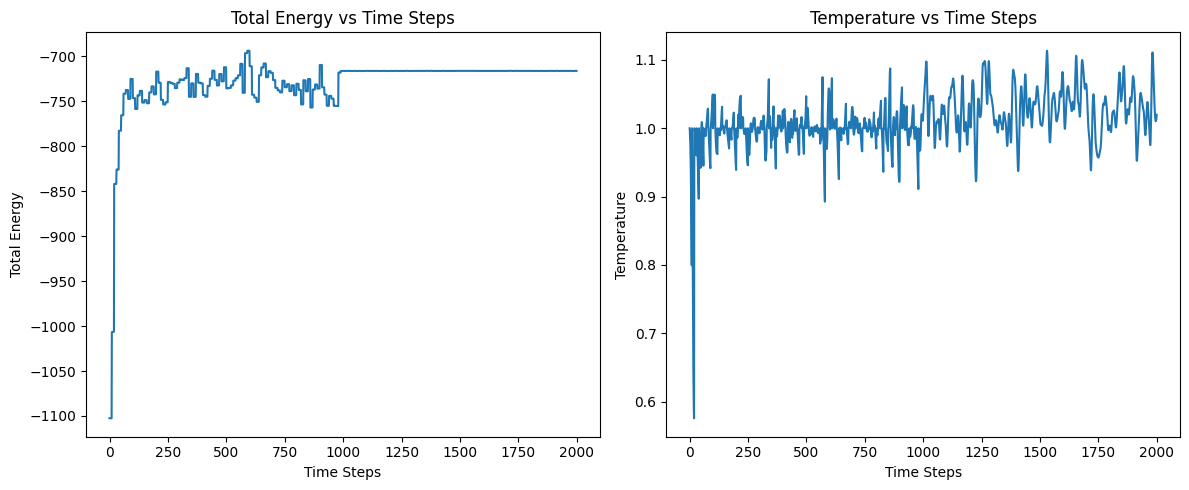

In [11]:
# --- THE MAIN MD LOOP ---
# 1. Setup: Define n_cells, density, T_target, dt, and steps.
# 2. Initialize: Call generate_fcc_lattice and initialize_velocities.
# 3. Main Loop:
#    - Call velocity_verlet_step (from Module 4)
#    - If in equilibration and step % 10 == 0: call rescale_velocities
#    - Accumulate energy and temperature data for plotting.

n_cells     = 4        
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff**2
r_skin     = 3.2
r_skin_sq = r_skin**2

pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)
pos_ref = pos.copy()
vel    = initialize_velocities(N, T_target)

# Initial forces

energies     = []
temperatures = []
neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2   # (0.7/2)^2 = 0.1225

for step in range(total_steps):
    pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq,neighbour_list)

    disp_sq = np.sum((pos - pos_ref)**2, axis=1)
    if np.any(disp_sq > rebuild_threshold_sq):
        neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
        pos_ref = pos.copy()


    # Rescale velocities every 10 steps during equilibration (first half)
    if step < total_steps // 2 and step % 10 == 0:
        vel = rescale_velocities(vel, T_target)

    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)
    temperatures.append(2 * ke / (3 * N))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(energies)
plt.title('Total Energy vs Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Total Energy')
plt.subplot(1, 2, 2)
plt.plot(temperatures)
plt.title('Temperature vs Time Steps')
plt.xlabel('Time Steps')
plt.ylabel('Temperature') 
plt.tight_layout()
plt.show()


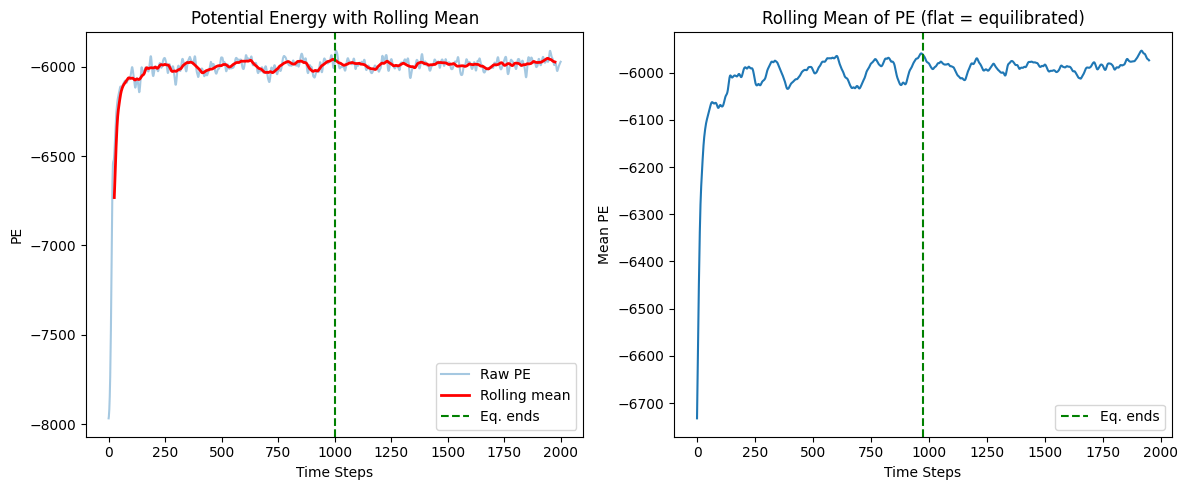

In [25]:
# --- THE MAIN MD LOOP ---
# 1. Setup: Define n_cells, density, T_target, dt, and steps.
# 2. Initialize: Call generate_fcc_lattice and initialize_velocities.
# 3. Main Loop:
#    - Call velocity_verlet_step (from Module 4)
#    - If in equilibration and step % 10 == 0: call rescale_velocities
#    - Accumulate energy and temperature data for plotting.

n_cells     = 7   
rho_star    = 0.8442
T_target    = 1.0
dt          = 0.005
total_steps = 2000
r_cutoff    = 2.5
r_cutoff_sq = r_cutoff**2
r_skin     = 3.2
r_skin_sq = r_skin**2

pos, L = generate_fcc_lattice(n_cells, rho_star)
N      = len(pos)
pos_ref = pos.copy()
vel    = initialize_velocities(N, T_target)

# Initial forces

energies     = []
temperatures = []
pe_list = []
neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
pe, force = calculate_forces_optimized(pos, neighbour_list, L, r_cutoff_sq)
rebuild_threshold_sq = 0.25 * (r_skin - r_cutoff)**2   # (0.7/2)^2 = 0.1225

for step in range(total_steps):
    pos, vel, pe, force = velocity_verlet_step_opt(pos, vel, force, dt, L, r_cutoff_sq,neighbour_list)

    disp_sq = np.sum((pos - pos_ref)**2, axis=1)
    if np.any(disp_sq > rebuild_threshold_sq):
        neighbour_list = update_neighbor_list(pos, L, r_skin_sq)
        pos_ref = pos.copy()


    # Rescale velocities every 10 steps during equilibration (first half)
    if step < total_steps // 2 and step % 10 == 0:
        vel = rescale_velocities(vel, T_target)

    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)
    pe_list.append(pe)
    temperatures.append(2 * ke / (3 * N))

# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(energies)
# plt.title('Total Energy vs Time Steps')
# plt.xlabel('Time Steps')
# plt.ylabel('Total Energy')
# plt.subplot(1, 2, 2)
# plt.plot(temperatures)
# plt.title('Temperature vs Time Steps')
# plt.xlabel('Time Steps')
# plt.ylabel('Temperature') 
# plt.tight_layout()
# plt.show()
# plt.close()
window = 50
rolling_means = [np.mean(pe_list[i:i+window]) for i in range(len(pe_list) - window)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(pe_list, alpha=0.4, label='Raw PE')
plt.plot(range(window//2, len(pe_list) - window//2), rolling_means, 
         color='red', linewidth=2, label='Rolling mean')
plt.axvline(x=total_steps//2, color='green', linestyle='--', label='Eq. ends')
plt.title('Potential Energy with Rolling Mean')
plt.xlabel('Time Steps')
plt.ylabel('PE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rolling_means)
plt.axvline(x=total_steps//2 - window//2, color='green', linestyle='--', label='Eq. ends')
plt.title('Rolling Mean of PE (flat = equilibrated)')
plt.xlabel('Time Steps')
plt.ylabel('Mean PE')
plt.legend()

plt.tight_layout()
plt.show()

# plt.plot(pe_list)
# plt.title('Potential Energy vs Time Steps')
# plt.xlabel('Time Steps')
# plt.ylabel('Potential Energy')
# plt.show()
